In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USERNAME')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("Ready")

Ready


In [2]:
df = pd.read_sql("SELECT * FROM food_distribution", engine)

print("Shape:", df.shape)
print(df.head())

Shape: (25, 12)
   distribution_id beneficiary_name  age  gender  province  district  \
0                1     Ahmad Karimi   45    Male     Kabul     Kabul   
1                2     Fatima Noori   32  Female     Kabul     Kabul   
2                3   Mohammad Yusuf   28    Male  Kandahar  Kandahar   
3                4   Zainab Hussain   38  Female     Herat     Herat   
4                5      Abdul Karim   67    Male     Kabul     Kabul   

   food_package_kg distribution_date    enumerator     status  household_size  \
0               25        2024-02-01  Enumerator_A  Completed               6   
1               25        2024-02-01  Enumerator_A  Completed               4   
2              100        2024-02-02  Enumerator_B  Completed               3   
3               25        2024-02-02  Enumerator_B  Completed               5   
4               25        2024-02-03  Enumerator_A  Completed               7   

   monthly_income_usd  
0               120.0  
1               

In [10]:
# Total food distributed per province
# Groupby province and reset province columns that has become index
food_by_province = df.groupby('province')['food_package_kg'].sum().reset_index()
# add descriptive name to columns
food_by_province.columns = ['province', 'total_food_kg']
# sort from big to small total_food_kg
food_by_province = food_by_province.sort_values(
    ['total_food_kg', 'province'],
    ascending=[False, True]
)

print(food_by_province)

   province  total_food_kg
2     Kabul            225
3  Kandahar            225
0     Balkh            125
1     Herat            125


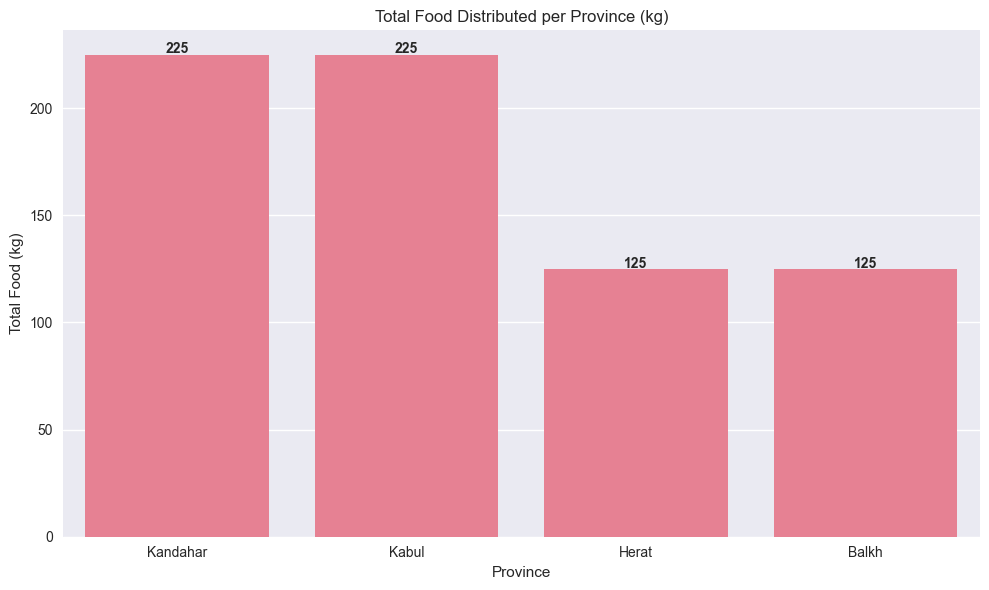

In [7]:
# Visualize
plt.figure()
ax = sns.barplot(data=food_by_province, x='province', y='total_food_kg')
for i, v in enumerate(food_by_province['total_food_kg']):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.title('Total Food Distributed per Province (kg)')
plt.xlabel('Province')
plt.ylabel('Total Food (kg)')
plt.tight_layout()
plt.show()

In [9]:
# In SQL
query = """
SELECT 
    province,
    SUM(food_package_kg) as total_food_kg
FROM food_distribution
GROUP BY province
ORDER BY total_food_kg DESC, province ASC
"""
result = pd.read_sql(query, engine)
print(result)

   province  total_food_kg
0     Kabul          225.0
1  Kandahar          225.0
2     Balkh          125.0
3     Herat          125.0


In [11]:
# Average income and household size by province
# named aggregation agg()
province_summary = df.groupby('province').agg(
    avg_income=('monthly_income_usd', 'mean'),
    avg_household=('household_size', 'mean'),
    beneficiary_count=('beneficiary_name', 'count')
).round(2).reset_index()

province_summary = province_summary.sort_values('avg_income')
print(province_summary)

   province  avg_income  avg_household  beneficiary_count
3  Kandahar       49.17           7.17                  6
0     Balkh       77.00           3.00                  5
1     Herat       86.00           4.40                  5
2     Kabul      124.44           5.44                  9


In [12]:
# SQL - ROUND requires ::numeric
query = """
SELECT 
    province,
    ROUND(AVG(monthly_income_usd)::numeric, 2) as avg_income,
    ROUND(AVG(household_size)::numeric, 2) as avg_household,
    COUNT(beneficiary_name) as beneficiary_count
FROM food_distribution
GROUP BY province
ORDER BY avg_income ASC
"""

result = pd.read_sql(query, engine)
print(result)

   province  avg_income  avg_household  beneficiary_count
0  Kandahar       49.17           7.17                  6
1     Balkh       77.00           3.00                  5
2     Herat       86.00           4.40                  5
3     Kabul      124.44           5.44                  9


In [ ]:
# Beneficiary summary by gender
gender_summary = df.groupby('gender').agg(
    count=('beneficiary_name', 'count'),
    avg_age=('age', 'mean'),
    avg_income=('monthly_income_usd', 'mean'),
    avg_household=('household_size', 'mean')
).round(2).reset_index()

print(gender_summary)

In [ ]:
# Visualize count
plt.figure()
ax = sns.barplot(data=gender_summary, x='gender', y='count')
for i, v in enumerate(gender_summary['count']):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.title('Beneficiaries by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()